# ConverterIQ — Episode-Aware Data Splitting and Baseline Modeling

This notebook uses the temporal structure established during EDA to create a leakage-aware
train / validation / test split.

Key principle:

- A raw row is one waveform snapshot.
- Consecutive rows with the same non-zero label form a candidate fault episode.
- Rows from the same fault episode must never appear in different dataset splits.

The split will be saved as a fixed manifest so that all later models use the same
train / validation / test sets.

## Notebook roadmap

This notebook has four goals:

1. Reconstruct the episode/block structure established during EDA and create a fixed, leakage-aware 70/15/15 train/validation/test split.
2. Apply the data-quality rule identified during EDA **after** the split is fixed, then construct model-ready arrays.
3. Establish classical baselines and develop a 1D CNN using the validation set only.
4. Lock the final CNN configuration and evaluate all final models once on the held-out test set.

**Primary model-selection metric:** macro F1. Because healthy records dominate the dataset, accuracy and weighted F1 are reported as complementary metrics, while balanced accuracy is used to assess class-balanced recall.


# 1. Episode-aware data splitting

### 1.1 Imports, paths, and minimal metadata

Only `row_id`, `timestamp`, and `id_error` are needed to reconstruct the temporal label structure. Rebuilding this metadata here keeps the modeling notebook independent from the EDA notebook.


In [2]:
from pathlib import Path

import ijson
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

In [3]:
DATA_PATH = Path("../data/id_mea_2.json")

RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

In [4]:
rows = []

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):
        rows.append({
            "row_id": i,
            "timestamp": float(record["timestamp"]),
            "id_error": int(record["id_error"]),
        })

meta = pd.DataFrame(rows)

print(meta.shape)
meta.head()

(386705, 3)


,row_id,timestamp,id_error
0,0,1.778622e+09,0
1,1,1.778622e+09,0
2,2,1.778622e+09,0
3,3,1.778622e+09,0
4,4,1.778622e+09,0


In [5]:
#Sanity checks
assert len(meta) == 386705
assert meta["id_error"].nunique() == 48
assert meta["row_id"].is_unique

print("Metadata checks passed.")

Metadata checks passed.


### 1.2 Reconstruct label runs and experimental blocks

A **label run** is a maximal sequence of consecutive rows with the same `id_error`. EDA showed a strict healthy → fault → healthy pattern with no fault → fault transition. We therefore pair each healthy run with the immediately following fault run as one **experimental block**.

Keeping the healthy context and the associated fault injection in the same block prevents near-duplicate or directly related measurements from being split across train, validation, and test sets.


In [6]:
meta["new_label_run"] = (
    meta["id_error"] != meta["id_error"].shift()
)

meta["label_run_id"] = (
    meta["new_label_run"]
    .cumsum()
    .astype(int)
)

print("Number of label runs:",
      meta["label_run_id"].nunique())

Number of label runs: 33627


In [7]:
run_summary = (
    meta.groupby("label_run_id")
    .agg(
        id_error=("id_error", "first"),
        start_row=("row_id", "first"),
        end_row=("row_id", "last"),
        n_records=("row_id", "size"),
    )
    .reset_index()
)

run_summary.head()

,label_run_id,id_error,start_row,end_row,n_records
0,1,0,0,6,7
1,2,12,7,13,7
2,3,0,14,32,19
3,4,12,33,40,8
4,5,0,41,56,16


In [8]:
run_summary["prev_label"] = (
    run_summary["id_error"].shift()
)

healthy_to_fault = (
    (run_summary["prev_label"] == 0)
    & (run_summary["id_error"] != 0)
).sum()

fault_to_healthy = (
    (run_summary["prev_label"] != 0)
    & (run_summary["id_error"] == 0)
).sum()

fault_to_fault = (
    (run_summary["prev_label"] != 0)
    & (run_summary["id_error"] != 0)
).sum()

print("Healthy -> Fault:", healthy_to_fault)
print("Fault -> Healthy:", fault_to_healthy)
print("Fault -> Fault:", fault_to_fault)

Healthy -> Fault: 16813
Fault -> Healthy: 16814
Fault -> Fault: 0


In [9]:
assert healthy_to_fault == 16813
assert fault_to_fault == 0

In [10]:
meta["block_id"] = (
    (meta["label_run_id"] + 1) // 2
).astype(int)

In [12]:
def get_fault_label(labels):
    fault_labels = labels[labels != 0]

    if len(fault_labels) == 0:
        return 0

    unique_faults = fault_labels.unique()

    if len(unique_faults) != 1:
        raise ValueError(
            f"Expected one fault label per block, "
            f"found {unique_faults}"
        )

    return int(unique_faults[0])

In [13]:
block_summary = (
    meta.groupby("block_id")
    .agg(
        fault_label=("id_error", get_fault_label),
        start_row=("row_id", "first"),
        end_row=("row_id", "last"),
        n_records=("row_id", "size"),
    )
    .reset_index()
)

print(block_summary.shape)
block_summary.head()

(16814, 5)


,block_id,fault_label,start_row,end_row,n_records
0,1,12,0,13,14
1,2,12,14,40,27
2,3,12,41,61,21
3,4,12,62,80,19
4,5,12,81,99,19


In [14]:
block_summary.tail()
print(
    block_summary["fault_label"]
    .eq(0)
    .value_counts()
)

fault_label
False    16813
True         1
Name: count, dtype: int64


In [15]:
fault_blocks = block_summary[
    block_summary["fault_label"] != 0
].copy()

healthy_only_blocks = block_summary[
    block_summary["fault_label"] == 0
].copy()

In [16]:
episode_counts = (
    fault_blocks["fault_label"]
    .value_counts()
    .sort_index()
)

episode_counts

print("Fault blocks:", len(fault_blocks))
print("Healthy-only blocks:", len(healthy_only_blocks))

Fault blocks: 16813
Healthy-only blocks: 1


### 1.3 Stratified 70/15/15 block split

The split unit is the **block**, not the raw row. Stratification is performed by fault label so that each fault class is represented at approximately the same episode-level proportion in train, validation, and test sets. The final healthy-only block is assigned to training.


In [ ]:
temp_ratio = VAL_RATIO + TEST_RATIO

train_blocks, temp_blocks = train_test_split(
    fault_blocks,
    test_size=temp_ratio,
    stratify=fault_blocks["fault_label"],
    random_state=RANDOM_STATE,
)

test_fraction_within_temp = TEST_RATIO / temp_ratio

val_blocks, test_blocks = train_test_split(
    temp_blocks,
    test_size=test_fraction_within_temp,
    stratify=temp_blocks["fault_label"],
    random_state=RANDOM_STATE,
)

train_blocks = pd.concat(
    [train_blocks, healthy_only_blocks],
    ignore_index=True,
)


In [20]:
print("Train blocks:", len(train_blocks))
print("Validation blocks:", len(val_blocks))
print("Test blocks:", len(test_blocks))

Train blocks: 11770
Validation blocks: 2522
Test blocks: 2522


In [21]:
total = (
    len(train_blocks)
    + len(val_blocks)
    + len(test_blocks)
)

print("\nRatios:")
print("Train:", len(train_blocks) / total)
print("Val:", len(val_blocks) / total)
print("Test:", len(test_blocks) / total)


Ratios:
Train: 0.7000118948495302
Val: 0.14999405257523493
Test: 0.14999405257523493


In [ ]:
split_episode_counts = pd.DataFrame({
    "train": (
        train_blocks.loc[train_blocks["fault_label"] != 0, "fault_label"]
        .value_counts()
        .sort_index()
    ),
    "val": (
        val_blocks["fault_label"]
        .value_counts()
        .sort_index()
    ),
    "test": (
        test_blocks["fault_label"]
        .value_counts()
        .sort_index()
    ),
})

split_episode_counts["total"] = split_episode_counts[["train", "val", "test"]].sum(axis=1)
split_episode_counts["train_ratio"] = split_episode_counts["train"] / split_episode_counts["total"]
split_episode_counts["val_ratio"] = split_episode_counts["val"] / split_episode_counts["total"]
split_episode_counts["test_ratio"] = split_episode_counts["test"] / split_episode_counts["total"]

split_episode_counts.head(10)


### 1.4 Leakage checks and row-level assignment

Three checks are enforced before modeling:

- no block appears in more than one split;
- no fault episode (`label_run_id`) crosses split boundaries;
- all 48 labels remain represented in every split.

After validation, each raw row inherits the split assignment of its block.


In [24]:
train_ids = set(train_blocks["block_id"])
val_ids = set(val_blocks["block_id"])
test_ids = set(test_blocks["block_id"])

In [25]:
print("Train ∩ Val:",
      len(train_ids & val_ids))

print("Train ∩ Test:",
      len(train_ids & test_ids))

print("Val ∩ Test:",
      len(val_ids & test_ids))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [26]:
assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("Block-level leakage check passed.")

Block-level leakage check passed.


In [27]:
split_map = {}

split_map.update({
    block_id: "train"
    for block_id in train_ids
})

split_map.update({
    block_id: "val"
    for block_id in val_ids
})

split_map.update({
    block_id: "test"
    for block_id in test_ids
})

meta["split"] = meta["block_id"].map(split_map)

In [28]:
print(meta["split"].isna().sum())

0


In [29]:
print(
    meta["split"]
    .value_counts()
)

print(
    meta["split"]
    .value_counts(normalize=True)
)

split
train    270688
val       58287
test      57730
Name: count, dtype: int64
split
train    0.699986
val      0.150727
test     0.149287
Name: proportion, dtype: float64


In [30]:
fault_rows = meta[
    meta["id_error"] != 0
]

episode_split_check = (
    fault_rows
    .groupby("label_run_id")["split"]
    .nunique()
)

print(
    "Fault episodes appearing in multiple splits:",
    (episode_split_check > 1).sum()
)

Fault episodes appearing in multiple splits: 0


In [31]:
assert (episode_split_check <= 1).all()

print("Fault episode leakage check passed.")

Fault episode leakage check passed.


In [32]:
row_class_counts = pd.crosstab(
    meta["id_error"],
    meta["split"]
)

row_class_counts

split,test,train,val
id_error,,,
0,41541,193861,41639
1,345,1657,386
2,345,1593,327
3,361,1633,312
4,310,1669,354
5,370,1692,362
6,347,1675,353
7,353,1564,355
8,347,1567,386


In [33]:
for split_name in ["train", "val", "test"]:
    n_labels = meta.loc[
        meta["split"] == split_name,
        "id_error"
    ].nunique()

    print(
        split_name,
        "number of labels:",
        n_labels
    )

train number of labels: 48
val number of labels: 48
test number of labels: 48


# 2. Data-quality filtering and model arrays

The split is fixed **before** filtering invalid rows so that data cleaning cannot alter the original temporal run/block structure. The saturation rule comes directly from the EDA audit: records containing values within 1% of ±\(2^{30}\) exhibit nonphysical rail/clipping artifacts and are excluded from model inputs. The raw JSON is never modified.


In [35]:
SAT_VALUE = 2**30
SAT_TOL = 0.01 * SAT_VALUE


def is_saturated(mea_value):
    values = np.asarray(mea_value, dtype=float)

    return np.any(
        np.abs(np.abs(values) - SAT_VALUE) <= SAT_TOL
    )

In [36]:
quality_rows = []

with DATA_PATH.open("rb") as f:
    for i, record in enumerate(ijson.items(f, "item")):
        quality_rows.append({
            "row_id": i,
            "is_saturated": is_saturated(
                record["mea_value"]
            ),
        })

quality_df = pd.DataFrame(quality_rows)

print(
    quality_df["is_saturated"]
    .value_counts()
)

is_saturated
False    386101
True        604
Name: count, dtype: int64


In [37]:
split_manifest = split_manifest.merge(
    quality_df,
    on="row_id",
    how="left",
    validate="one_to_one",
)

split_manifest["is_valid"] = (
    ~split_manifest["is_saturated"]
)

split_manifest["exclude_reason"] = np.where(
    split_manifest["is_saturated"],
    "near_2pow30_saturation_artifact",
    ""
)

In [38]:
print(
    "Total rows:",
    len(split_manifest)
)

print(
    "Valid rows:",
    split_manifest["is_valid"].sum()
)

print(
    "Excluded rows:",
    (~split_manifest["is_valid"]).sum()
)

Total rows: 386705
Valid rows: 386101
Excluded rows: 604


In [39]:
quality_by_split = pd.crosstab(
    split_manifest["split"],
    split_manifest["is_saturated"],
)

quality_by_split

is_saturated,False,True
split,,
test,57639,91
train,270235,453
val,58227,60


In [40]:
model_manifest = split_manifest[
    split_manifest["is_valid"]
].copy()

In [41]:
for split_name in ["train", "val", "test"]:

    subset = model_manifest[
        model_manifest["split"] == split_name
    ]

    print(
        split_name,
        "rows =", len(subset),
        "labels =", subset["id_error"].nunique()
    )

train rows = 270235 labels = 48
val rows = 58227 labels = 48
test rows = 57639 labels = 48


In [42]:
all_fault_episode_ids = set(
    split_manifest.loc[
        split_manifest["id_error"] != 0,
        "label_run_id"
    ]
)

valid_fault_episode_ids = set(
    model_manifest.loc[
        model_manifest["id_error"] != 0,
        "label_run_id"
    ]
)

lost_fault_episodes = (
    all_fault_episode_ids
    - valid_fault_episode_ids
)

print(
    "Fault episodes completely removed:",
    len(lost_fault_episodes)
)

Fault episodes completely removed: 0


In [43]:
valid_episode_counts = (
    model_manifest[
        model_manifest["id_error"] != 0
    ]
    .groupby(
        ["split", "id_error"]
    )["label_run_id"]
    .nunique()
    .unstack(0)
)

valid_episode_counts

split,test,train,val
id_error,,,
1,52,245,53
2,52,245,53
3,53,245,52
4,52,245,53
5,53,245,52
6,52,245,53
7,53,245,52
8,53,245,52
9,52,245,53


No complete fault episode should disappear after row-level quality filtering. The checks above verify that all fault episodes still contain at least one valid record.


In [44]:
split_manifest.to_csv(
    "../data/split_manifest.csv",
    index=False
)

In [45]:
model_manifest.to_csv(
    "../data/model_manifest.csv",
    index=False
)

### 2.1 Construct `(N, 20, 3)` waveform tensors

The raw `mea_value` layout is block-wise: `A0...A19, B0...B19, C0...C19`. Reshaping with `reshape(3, 20).T` produces a 20-timestep × 3-phase tensor while preserving the electrical-cycle structure.


In [46]:
model_manifest = (
    model_manifest
    .sort_values("row_id")
    .reset_index(drop=True)
)

In [47]:
n_samples = len(model_manifest)

X = np.empty(
    (n_samples, 20, 3),
    dtype=np.float32
)

y = model_manifest[
    "id_error"
].to_numpy(
    dtype=np.int32
)

In [48]:
row_to_position = {
    row_id: pos
    for pos, row_id
    in enumerate(
        model_manifest["row_id"]
    )
}

In [ ]:
with DATA_PATH.open("rb") as f:

    for row_id, record in enumerate(
        ijson.items(f, "item")
    ):

        pos = row_to_position.get(row_id)

        if pos is None:
            continue

        values = np.asarray(
            record["mea_value"],
            dtype=np.float32
        )

        X[pos] = values.reshape(3, 20).T

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print(
    "NaN in X:",
    np.isnan(X).any()
)

print(
    "Inf in X:",
    np.isinf(X).any()
)

X shape: (386101, 20, 3)
y shape: (386101,)
X dtype: float32
y dtype: int32
NaN in X: False
Inf in X: False


In [ ]:
split_labels = (
    model_manifest["split"]
    .to_numpy()
)

train_mask = split_labels == "train"
val_mask = split_labels == "val"
test_mask = split_labels == "test"

In [ ]:
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

In [ ]:
print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Val:",
    X_val.shape,
    y_val.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (270235, 20, 3) (270235,)
Val: (58227, 20, 3) (58227,)
Test: (57639, 20, 3) (57639,)


In [ ]:
assert (
    len(X_train)
    + len(X_val)
    + len(X_test)
    == len(model_manifest)
)

assert len(np.unique(y_train)) == 48
assert len(np.unique(y_val)) == 48
assert len(np.unique(y_test)) == 48

print("Model arrays passed sanity checks.")

Model arrays passed sanity checks.


The held-out test set is constructed here but is not used for preprocessing decisions, architecture selection, class-weight tuning, or early stopping.


In [ ]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(
    OUTPUT_DIR / "X_train.npy",
    X_train
)

np.save(
    OUTPUT_DIR / "y_train.npy",
    y_train
)

np.save(
    OUTPUT_DIR / "X_val.npy",
    X_val
)

np.save(
    OUTPUT_DIR / "y_val.npy",
    y_val
)

np.save(
    OUTPUT_DIR / "X_test.npy",
    X_test
)

np.save(
    OUTPUT_DIR / "y_test.npy",
    y_test
)

In [ ]:
split_manifest.to_csv(
    OUTPUT_DIR / "split_manifest.csv",
    index=False
)

model_manifest.to_csv(
    OUTPUT_DIR / "model_manifest.csv",
    index=False
)

# 3. Classical baselines

Tree-based baselines use a flattened 60-feature representation. The CNN later receives the original `(20, 3)` sequence.

Because the healthy class dominates the dataset, **macro F1 is the primary selection metric**. Accuracy and weighted F1 emphasize the majority class, while balanced accuracy summarizes average class recall.


In [164]:
X_train_flat = X_train.reshape(
    len(X_train),
    -1
)

X_val_flat = X_val.reshape(
    len(X_val),
    -1
)

print(X_train_flat.shape)
print(X_val_flat.shape)

(270235, 60)
(58227, 60)


In [165]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    X_train_flat,
    y_train
)

y_val_pred_dummy = dummy.predict(
    X_val_flat
)

In [166]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

def evaluate_model(y_true, y_pred, name):
    results = {
        "model": name,
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted"
        ),
    }

    return results

In [167]:
dummy_results = evaluate_model(
    y_val,
    y_val_pred_dummy,
    "Dummy - Most Frequent"
)

dummy_results

{'model': 'Dummy - Most Frequent',
 'accuracy': 0.7146512786164494,
 'balanced_accuracy': 0.020833333333333332,
 'macro_f1': 0.017366293065168254,
 'weighted_f1': 0.5957204901048226}

In [168]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=None,
)

dt.fit(
    X_train_flat,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_f

In [169]:
y_val_pred_dt = dt.predict(
    X_val_flat
)

dt_results = evaluate_model(
    y_val,
    y_val_pred_dt,
    "Decision Tree"
)

dt_results

{'model': 'Decision Tree',
 'accuracy': 0.8563896474144297,
 'balanced_accuracy': 0.6351422010945291,
 'macro_f1': 0.6381998716362265,
 'weighted_f1': 0.8535686959847331}

In [171]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)

rf.fit(
    X_train_flat,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

In [172]:
y_val_pred_rf = rf.predict(
    X_val_flat
)

rf_results = evaluate_model(
    y_val,
    y_val_pred_rf,
    "Random Forest"
)

rf_results

{'model': 'Random Forest',
 'accuracy': 0.8793171552716094,
 'balanced_accuracy': 0.6205128268923267,
 'macro_f1': 0.6316857108110384,
 'weighted_f1': 0.8615371594226623}

In [ ]:
baseline_results = pd.DataFrame([
    dummy_results,
    dt_results,
    rf_results,
])

baseline_results

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy - Most Frequent,0.714651,0.020833,0.017366,0.595720
1,Decision Tree,0.856390,0.635142,0.638200,0.853569
2,Random Forest,0.879317,0.620513,0.631686,0.861537


The classical baselines establish two useful reference points: Random Forest gives the strongest overall accuracy/weighted F1, while Decision Tree provides a competitive macro-F1 baseline. Detailed per-class reports are omitted here to keep the notebook focused; final per-class analysis is performed for the selected CNN on the held-out test set.


# 4. CNN preprocessing

The training distribution has a heavy upper tail: most current samples are in the few-thousand range, while a small fraction are orders of magnitude larger. Ordinary mean/std standardization would therefore be dominated by the tail.

We use a signed `asinh` transform,

\[
x' = \operatorname{asinh}(x/s_c),
\]

where \(s_c\) is the **training-set median absolute value for each phase**. This compresses extreme magnitudes while preserving sign and amplitude ordering. All scale parameters are estimated from training data only and then reused unchanged for validation, test, and inference.


In [ ]:
train_values = X_train.reshape(-1, 3)

percentiles = [50, 90, 95, 99, 99.5, 99.9, 99.99]

for phase in range(3):
    values = np.abs(train_values[:, phase])

    print(f"\nPhase {phase}")

    for p in percentiles:
        print(
            f"{p:>6}%: "
            f"{np.percentile(values, p):.3f}"
        )

    print("mean:", values.mean())
    print("std :", values.std())
    print("max :", values.max())


Phase 0
    50%: 3840.256
    90%: 6202.996
    95%: 6477.709
    99%: 13182801.000
  99.5%: 42485844.000
  99.9%: 408819776.000
 99.99%: 832553024.000
mean: 1.3116779e+06
std : 2.223202e+07
max : 1.0626104e+09

Phase 1
    50%: 3853.792
    90%: 6176.254
    95%: 6426.912
    99%: 10810872.000
  99.5%: 35153680.000
  99.9%: 325519264.000
 99.99%: 801295872.000
mean: 1.1156145e+06
std : 2.0041834e+07
max : 1.0628557e+09

Phase 2
    50%: 3835.450
    90%: 6167.113
    95%: 6417.966
    99%: 5337057.000
  99.5%: 18767934.000
  99.9%: 185597248.000
 99.99%: 696052928.000
mean: 706450.2
std : 1.5091406e+07
max : 1.062036e+09


In [ ]:
channel_scale = np.median(
    np.abs(X_train),
    axis=(0, 1)
)

print(channel_scale)

[3840.256  3853.792  3835.4497]


In [ ]:
def asinh_scale(X, scale):
    return np.arcsinh(
        X / scale.reshape(1, 1, 3)
    ).astype(np.float32)

In [ ]:
X_train_scaled = asinh_scale(
    X_train,
    channel_scale
)

X_val_scaled = asinh_scale(
    X_val,
    channel_scale
)

X_test_scaled = asinh_scale(
    X_test,
    channel_scale
)

In [ ]:
for name, X_split in [
    ("train", X_train_scaled),
    ("val", X_val_scaled),
]:
    print(f"\n{name}")
    print(
        "min =", X_split.min(),
        "max =", X_split.max(),
        "mean =", X_split.mean(),
        "std =", X_split.std(),
    )


In [ ]:
for phase in range(3):
    values = np.abs(X_train_scaled[:, :, phase]).ravel()

    print(f"\nPhase {phase}")
    for p in [50, 90, 95, 99, 99.9, 99.99]:
        print(f"{p}%:", np.percentile(values, p))


# Save preprocessing parameters

In [ ]:
np.save(
    "../data/processed/channel_scale.npy",
    channel_scale
)

In [ ]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())


# 5. CNN development and ablation summary

Early exploratory runs identified three important design choices before the systematic search:

| Configuration | Accuracy | Balanced accuracy | Macro F1 | Main finding |
|---|---:|---:|---:|---|
| No BN, no class weight, global average pooling | 0.844 | 0.464 | 0.454 | Stable, but strongly favors easy/healthy classes |
| Global average pooling, α=0.50 | 0.799 | 0.518 | 0.489 | Moderate weighting improves minority recall |
| Global average pooling, α=0.75 | 0.542 | 0.602 | 0.477 | Weighting becomes too aggressive |
| **Flatten, α=0.50** | 0.773 | **0.647** | 0.588 | Preserving temporal position substantially improves class-balanced performance |
| **Flatten, α=0.40** | **0.822** | 0.620 | **0.591** | Better precision/recall trade-off |

Two conclusions guided the systematic search below:

1. **Batch normalization was removed** because it produced unstable validation behavior on this heavy-tailed dataset.
2. **Flatten replaced global average pooling** because waveform position within the 20-sample electrical cycle carries discriminative information.

The class-weight exponent `alpha` controls the strength of imbalance correction: `alpha=0` gives no weighting, while larger values increasingly emphasize minority fault classes.


## 5.1 Stage 2: targeted kernel-size / class-weight search

A targeted search evaluates kernel sizes 5 and 7 with `alpha ∈ {0.35, 0.40, 0.45}`. Each candidate uses the same no-BN, no-pooling, Flatten architecture. Validation macro-F1 is computed on the **entire validation set** after every epoch and is used to restore the best weights.


In [ ]:
RANDOM_STATE = 42
NUM_CLASSES = 48
BATCH_SIZE = 256
PRED_BATCH_SIZE = 512
MAX_EPOCHS = 35

OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
classes = np.arange(NUM_CLASSES)

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

counts = np.bincount(
    y_train,
    minlength=NUM_CLASSES
)

print("Class 0 count:", counts[0])
print(
    "Fault class count range:",
    counts[1:].min(),
    counts[1:].max()
)

In [ ]:
def make_class_weight(alpha):

    weights = balanced_weights ** alpha

    sample_weight_mean = (
        counts * weights
    ).sum() / counts.sum()

    weights = (
        weights / sample_weight_mean
    )

    class_weight = {
        int(c): float(w)
        for c, w in zip(
            classes,
            weights
        )
    }

    return class_weight

In [ ]:
def build_stage2_cnn(
    kernel_size,
    dropout=0.3,
    dense_units=64
):

    model = keras.Sequential([
        layers.Input(
            shape=(20, 3)
        ),

        layers.Conv1D(
            filters=32,
            kernel_size=kernel_size,
            padding="same",
            activation="relu"
        ),

        layers.Conv1D(
            filters=64,
            kernel_size=kernel_size,
            padding="same",
            activation="relu"
        ),

        layers.Conv1D(
            filters=128,
            kernel_size=kernel_size,
            padding="same",
            activation="relu"
        ),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu"
        ),

        layers.Dropout(
            dropout
        ),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    return model

In [ ]:
class ValMacroF1Callback(
    keras.callbacks.Callback
):

    def __init__(
        self,
        X_val,
        y_val,
        batch_size=512
    ):

        super().__init__()

        self.X_val = X_val
        self.y_val = y_val
        self.batch_size = batch_size

        self.best_f1 = -np.inf
        self.best_epoch = None
        self.best_weights = None

        self.f1_history = []


    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        prob = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0
        )

        pred = np.argmax(
            prob,
            axis=1
        )

        macro_f1 = f1_score(
            self.y_val,
            pred,
            average="macro",
            zero_division=0
        )

        self.f1_history.append(
            macro_f1
        )

        if logs is not None:
            logs["val_macro_f1"] = macro_f1

        print(
            f" — val_macro_f1: "
            f"{macro_f1:.4f}"
        )

        if macro_f1 > self.best_f1:

            self.best_f1 = macro_f1

            self.best_epoch = (
                epoch + 1
            )

            self.best_weights = (
                self.model.get_weights()
            )


    def on_train_end(
        self,
        logs=None
    ):

        if self.best_weights is not None:

            self.model.set_weights(
                self.best_weights
            )

        print(
            "\nRestored best "
            "macro-F1 weights:"
        )

        print(
            f"Epoch: {self.best_epoch}"
        )

        print(
            f"Validation Macro-F1: "
            f"{self.best_f1:.4f}"
        )

In [ ]:
stage2_configs = []

for kernel_size in [5, 7]:

    for alpha in [
        0.35,
        0.40,
        0.45
    ]:

        stage2_configs.append({

            "name":
                f"k{kernel_size}_a{alpha}",

            "kernel_size":
                kernel_size,

            "alpha":
                alpha,
        })


stage2_configs

In [ ]:
stage2_results = []

stage2_histories = {}

best_overall_macro_f1 = -np.inf
best_overall_name = None
best_overall_model_path = (
    OUTPUT_DIR /
    "best_stage2_cnn.keras"
)

In [ ]:
for experiment_num, cfg in enumerate(
    stage2_configs,
    start=1
):

    print("\n")
    print("=" * 75)

    print(
        f"Experiment "
        f"{experiment_num}/"
        f"{len(stage2_configs)}"
    )

    print(
        f"Name: {cfg['name']}"
    )

    print(
        f"Kernel size: "
        f"{cfg['kernel_size']}"
    )

    print(
        f"Alpha: {cfg['alpha']}"
    )

    print("=" * 75)


    # --------------------------------------------------------
    # Clear previous TensorFlow graph/model state
    # --------------------------------------------------------

    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(
        RANDOM_STATE
    )


    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    model = build_stage2_cnn(
        kernel_size=cfg[
            "kernel_size"
        ]
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(

        optimizer=
        keras.optimizers.Adam(
            learning_rate=1e-3
        ),

        loss=
        "sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    # --------------------------------------------------------
    # Class weights
    # --------------------------------------------------------

    class_weight = make_class_weight(
        cfg["alpha"]
    )


    # --------------------------------------------------------
    # Macro-F1 callback
    # --------------------------------------------------------

    macro_f1_cb = (
        ValMacroF1Callback(
            X_val_scaled,
            y_val,
            batch_size=
                PRED_BATCH_SIZE
        )
    )


    # --------------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------------

    reduce_lr_cb = (
        keras.callbacks
        .ReduceLROnPlateau(

            monitor="val_loss",

            factor=0.5,

            patience=2,

            min_lr=1e-6,

            verbose=0
        )
    )


    # --------------------------------------------------------
    # Train
    #
    # IMPORTANT:
    # no EarlyStopping here.
    # Every candidate gets the same 35-epoch budget.
    # Macro-F1 callback restores best epoch.
    # --------------------------------------------------------

    history = model.fit(

        X_train_scaled,
        y_train,

        validation_data=(
            X_val_scaled,
            y_val
        ),

        epochs=MAX_EPOCHS,

        batch_size=BATCH_SIZE,

        class_weight=
            class_weight,

        callbacks=[
            macro_f1_cb,
            reduce_lr_cb
        ],

        verbose=0
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    history_df = pd.DataFrame(
        history.history
    )

    history_df[
        "val_macro_f1"
    ] = macro_f1_cb.f1_history

    stage2_histories[
        cfg["name"]
    ] = history_df


    # --------------------------------------------------------
    # Fresh validation prediction
    #
    # model weights have already been restored
    # to best Macro-F1 epoch.
    # --------------------------------------------------------

    val_prob = model.predict(

        X_val_scaled,

        batch_size=
            PRED_BATCH_SIZE,

        verbose=0
    )


    val_pred = np.argmax(
        val_prob,
        axis=1
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    balanced_acc = (
        balanced_accuracy_score(
            y_val,
            val_pred
        )
    )

    macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    pred_healthy = np.mean(
        val_pred == 0
    )


    # --------------------------------------------------------
    # Save experiment summary
    # --------------------------------------------------------

    result = {

        "name":
            cfg["name"],

        "kernel_size":
            cfg["kernel_size"],

        "alpha":
            cfg["alpha"],

        "accuracy":
            accuracy,

        "balanced_accuracy":
            balanced_acc,

        "macro_f1":
            macro_f1,

        "weighted_f1":
            weighted_f1,

        "pred_healthy":
            pred_healthy,

        "best_epoch":
            macro_f1_cb.best_epoch,

        "epochs_run":
            len(
                history.history[
                    "loss"
                ]
            ),

        "params":
            model.count_params(),
    }


    stage2_results.append(
        result
    )


    print("\nRESULT:")

    print(result)


    # --------------------------------------------------------
    # Save best model seen so far
    # --------------------------------------------------------

    if macro_f1 > best_overall_macro_f1:

        best_overall_macro_f1 = (
            macro_f1
        )

        best_overall_name = (
            cfg["name"]
        )

        model.save(
            best_overall_model_path
        )

        print(
            "\n*** New best "
            "Stage 2 model saved ***"
        )

        print(
            "Model:",
            best_overall_name
        )

        print(
            "Macro-F1:",
            best_overall_macro_f1
        )

In [150]:
stage2_df = pd.DataFrame(
    stage2_results
)

stage2_df = (
    stage2_df
    .sort_values(
        by="macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

stage2_df

,name,kernel_size,alpha,accuracy,balanced_accuracy,macro_f1,weighted_f1,pred_healthy,best_epoch,epochs_run,params
0,k7_a0.45,7,0.45,0.775482,0.727540,0.640656,0.809939,0.576966,35,35,239600
1,k5_a0.45,5,0.45,0.778161,0.718190,0.638387,0.811402,0.584900,35,35,218928
2,k5_a0.4,5,0.40,0.795731,0.702188,0.636853,0.822373,0.611933,35,35,218928
3,k7_a0.4,7,0.40,0.799595,0.692564,0.634160,0.823921,0.622443,35,35,239600
4,k5_a0.35,5,0.35,0.816649,0.672422,0.633652,0.833833,0.652275,35,35,218928
5,k7_a0.35,7,0.35,0.830439,0.659594,0.629135,0.839248,0.676336,35,35,239600


All six Stage 2 candidates reached their best macro-F1 at the 35-epoch budget boundary, indicating that the search had not fully converged. Stage 3 therefore extends only the four strongest finalists instead of expanding the architecture search further.


## 5.2 Stage 3: finalist search

The four finalists are trained for up to 70 epochs. Early stopping and learning-rate reduction monitor **validation macro-F1**, which matches the primary model-selection objective. The test set remains untouched.


In [ ]:
# ============================================================
# Stage 3 — Final validation sweep
# ============================================================

stage3_configs = [
    {"name": "k5_a040", "kernel_size": 5, "alpha": 0.40},
    {"name": "k5_a045", "kernel_size": 5, "alpha": 0.45},
    {"name": "k7_a040", "kernel_size": 7, "alpha": 0.40},
    {"name": "k7_a045", "kernel_size": 7, "alpha": 0.45},
]

stage3_results = []

for cfg in stage3_configs:

    print("\n" + "=" * 70)
    print(cfg["name"])
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    # Build same no-BN, no-pooling, Flatten CNN
    model = build_stage2_cnn(
        kernel_size=cfg["kernel_size"]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    class_weight = make_class_weight(
        cfg["alpha"]
    )

    macro_f1_cb = ValMacroF1Callback(
        X_val_scaled,
        y_val,
        batch_size=512
    )

    early_stop_cb = keras.callbacks.EarlyStopping(
        monitor="val_macro_f1",
        mode="max",
        patience=8,
        restore_best_weights=False,
        verbose=0
    )

    reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=0
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(
            X_val_scaled,
            y_val
        ),
        epochs=70,
        batch_size=256,
        class_weight=class_weight,
        callbacks=[
            macro_f1_cb,
            early_stop_cb,
            reduce_lr_cb
        ],
        verbose=0
    )

    # Fresh validation prediction using restored best Macro-F1 weights
    val_prob = model.predict(
        X_val_scaled,
        batch_size=512,
        verbose=0
    )

    val_pred = np.argmax(
        val_prob,
        axis=1
    )

    accuracy = accuracy_score(
        y_val,
        val_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_val,
        val_pred
    )

    macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val,
        val_pred,
        average="weighted",
        zero_division=0
    )

    pred_healthy = np.mean(
        val_pred == 0
    )

    healthy_mask = (
        y_val == 0
    )

    healthy_recall = np.mean(
        val_pred[healthy_mask] == 0
    )

    result = {
        "name": cfg["name"],
        "kernel_size": cfg["kernel_size"],
        "alpha": cfg["alpha"],
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "pred_healthy": pred_healthy,
        "healthy_recall": healthy_recall,
        "healthy_false_alarm_rate": 1 - healthy_recall,
        "best_epoch": macro_f1_cb.best_epoch,
        "epochs_run": len(history.history["loss"]),
        "params": model.count_params(),
    }

    stage3_results.append(result)

    print("\nRESULT:")
    print(result)

In [152]:
stage3_df = (
    pd.DataFrame(stage3_results)
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

stage3_df

,name,kernel_size,alpha,accuracy,balanced_accuracy,macro_f1,weighted_f1,pred_healthy,healthy_recall,healthy_false_alarm_rate,best_epoch,epochs_run,params
0,k5_a040,5,0.40,0.789926,0.740845,0.658948,0.821847,0.587013,0.808084,0.191916,70,70,218928
1,k5_a045,5,0.45,0.778007,0.744904,0.655803,0.813875,0.571882,0.789700,0.210300,69,70,218928
2,k7_a045,7,0.45,0.777955,0.743430,0.655100,0.813219,0.573806,0.790253,0.209747,65,70,239600
3,k7_a040,7,0.40,0.793824,0.726140,0.653966,0.823674,0.599155,0.819788,0.180212,69,70,239600


### Final CNN selection

`k5_a040` is selected because it has the highest validation macro-F1 (**0.659**) while retaining a lower healthy false-alarm rate than the more aggressively weighted `α=0.45` alternatives. Model selection is frozen at this point; no test-set result is used to change the architecture or hyperparameters.


In [ ]:
# ============================================================
# Final selected CNN
# kernel_size = 5
# alpha = 0.40
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

final_cnn = build_stage2_cnn(
    kernel_size=5
)

final_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_class_weight = make_class_weight(
    0.40
)

final_macro_f1_cb = ValMacroF1Callback(
    X_val_scaled,
    y_val,
    batch_size=512
)

final_early_stop = keras.callbacks.EarlyStopping(
    monitor="val_macro_f1",
    mode="max",
    patience=8,
    restore_best_weights=False,
    verbose=1
)

final_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_macro_f1",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

final_history = final_cnn.fit(
    X_train_scaled,
    y_train,
    validation_data=(
        X_val_scaled,
        y_val
    ),
    epochs=70,
    batch_size=256,
    class_weight=final_class_weight,
    callbacks=[
        final_macro_f1_cb,
        final_early_stop,
        final_reduce_lr
    ],
    verbose=1
)

In [154]:
FINAL_MODEL_PATH = (
    "../data/processed/final_cnn_k5_alpha040.keras"
)

final_cnn.save(
    FINAL_MODEL_PATH
)

print("Saved:", FINAL_MODEL_PATH)
print(
    "Best validation epoch:",
    final_macro_f1_cb.best_epoch
)
print(
    "Best validation Macro-F1:",
    final_macro_f1_cb.best_f1
)

Saved: ../data/processed/final_cnn_k5_alpha040.keras
Best validation epoch: 70
Best validation Macro-F1: 0.658947592824754


# 6. Held-out test evaluation

The test set is opened only after the architecture (`kernel_size=5`) and class-weight exponent (`alpha=0.40`) have been fixed. Test results are used for final reporting only, not for additional tuning.


In [155]:
test_prob = final_cnn.predict(
    X_test_scaled,
    batch_size=512,
    verbose=0
)

y_test_pred = np.argmax(
    test_prob,
    axis=1
)

In [156]:
test_results = {
    "model": "Final 1D CNN - k5 alpha=0.40",

    "accuracy":
        accuracy_score(
            y_test,
            y_test_pred
        ),

    "balanced_accuracy":
        balanced_accuracy_score(
            y_test,
            y_test_pred
        ),

    "macro_f1":
        f1_score(
            y_test,
            y_test_pred,
            average="macro",
            zero_division=0
        ),

    "weighted_f1":
        f1_score(
            y_test,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),

    "pred_healthy":
        np.mean(
            y_test_pred == 0
        ),
}

test_results

{'model': 'Final 1D CNN - k5 alpha=0.40',
 'accuracy': 0.7944273842363677,
 'balanced_accuracy': 0.7404464680470939,
 'macro_f1': 0.6573146448516998,
 'weighted_f1': 0.8264318432405514,
 'pred_healthy': np.float64(0.5975294505456376)}

In [157]:
healthy_test_mask = (
    y_test == 0
)

healthy_test_recall = np.mean(
    y_test_pred[
        healthy_test_mask
    ] == 0
)

test_results[
    "healthy_recall"
] = healthy_test_recall

test_results[
    "healthy_false_alarm_rate"
] = (
    1 - healthy_test_recall
)

test_results

{'model': 'Final 1D CNN - k5 alpha=0.40',
 'accuracy': 0.7944273842363677,
 'balanced_accuracy': 0.7404464680470939,
 'macro_f1': 0.6573146448516998,
 'weighted_f1': 0.8264318432405514,
 'pred_healthy': np.float64(0.5975294505456376),
 'healthy_recall': np.float64(0.8153067373749548),
 'healthy_false_alarm_rate': np.float64(0.18469326262504515)}

In [158]:
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0      0.982     0.815     0.891     41485
           1      0.228     0.890     0.363       345
           2      0.244     0.774     0.371       345
           3      0.890     0.895     0.892       361
           4      0.877     0.871     0.874       310
           5      0.229     0.838     0.360       370
           6      0.882     0.948     0.914       347
           7      0.945     0.875     0.909       353
           8      0.835     0.934     0.882       347
           9      0.927     0.820     0.870       356
          10      0.899     0.891     0.895       321
          11      0.890     0.898     0.894       315
          12      1.000     1.000     1.000       339
          13      1.000     1.000     1.000       394
          14      1.000     1.000     1.000       359
          15      1.000     1.000     1.000       424
          16      0.509     0.070     0.124       384
          17      0.260    

In [159]:
final_test_report = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        output_dict=True,
        zero_division=0
    )
).T

final_test_report.to_csv(
    "../data/processed/final_cnn_test_classification_report.csv"
)

pd.DataFrame(
    [test_results]
).to_csv(
    "../data/processed/final_cnn_test_metrics.csv",
    index=False
)

### Test confusion analysis

The normalized confusion matrix and top confusion pairs reveal that the remaining errors are concentrated in a small number of hard fault families rather than being uniformly distributed across classes.


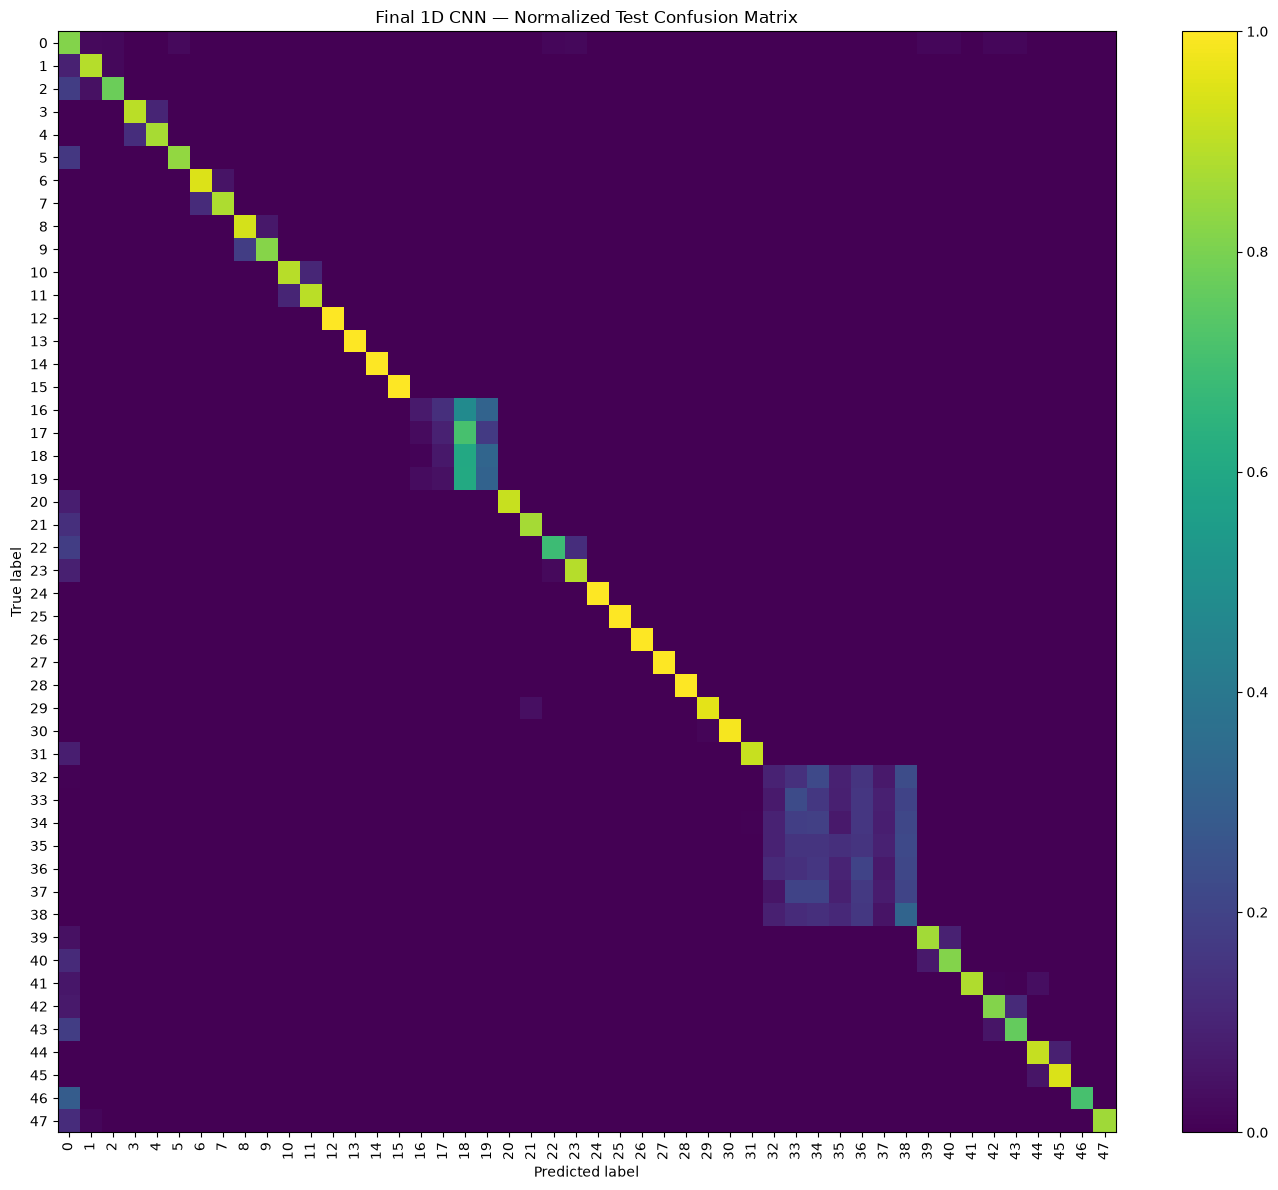

In [161]:
import matplotlib.pyplot as plt
cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(14, 12)
)

im = ax.imshow(
    cm_test,
    aspect="auto"
)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_title(
    "Final 1D CNN — Normalized Test Confusion Matrix"
)

ax.set_xticks(range(48))
ax.set_yticks(range(48))

ax.set_xticklabels(
    range(48),
    rotation=90
)

ax.set_yticklabels(
    range(48)
)

fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()
plt.show()

In [162]:
confusion_rows = []

for true_label in range(48):

    row = cm_test[true_label].copy()

    row[true_label] = 0

    wrong_label = np.argmax(row)
    wrong_rate = row[wrong_label]

    confusion_rows.append({
        "true_label": true_label,
        "most_confused_with": wrong_label,
        "confusion_rate": wrong_rate,
    })

final_confusion_summary = (
    pd.DataFrame(confusion_rows)
    .sort_values(
        "confusion_rate",
        ascending=False
    )
)

final_confusion_summary.head(20)

,true_label,most_confused_with,confusion_rate
17,17,18,0.707042
19,19,18,0.606599
16,16,18,0.476562
18,18,19,0.324397
46,46,0,0.289855
32,32,38,0.231544
35,35,38,0.222222
36,36,38,0.213699
34,34,38,0.211594
37,37,38,0.204986


## 6.1 Final comparison with classical baselines

In [173]:
X_test_flat = X_test.reshape(
    len(X_test),
    -1
)

y_test_pred_dt = dt.predict(
    X_test_flat
)

y_test_pred_rf = rf.predict(
    X_test_flat
)

dt_test_results = evaluate_model(
    y_test,
    y_test_pred_dt,
    "Decision Tree"
)

rf_test_results = evaluate_model(
    y_test,
    y_test_pred_rf,
    "Random Forest"
)

cnn_test_results = evaluate_model(
    y_test,
    y_test_pred,
    "Final 1D CNN"
)

final_model_comparison = pd.DataFrame([
    dt_test_results,
    rf_test_results,
    cnn_test_results,
])

final_model_comparison

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Decision Tree,0.861066,0.640033,0.640501,0.859717
1,Random Forest,0.884141,0.622790,0.634413,0.868589
2,Final 1D CNN,0.794427,0.740446,0.657315,0.826432


# 7. Final model comparison and selection

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|
| Decision Tree | 0.861 | 0.640 | 0.641 | 0.860 |
| Random Forest | **0.884** | 0.623 | 0.634 | **0.869** |
| Final 1D CNN | 0.794 | **0.740** | **0.657** | 0.826 |

The Random Forest achieves the highest overall accuracy and weighted F1, while the final 1D CNN achieves the highest balanced accuracy and macro F1. Because healthy records dominate the dataset, macro F1 is the primary metric for the multi-class fault-classification objective.

The CNN is therefore selected as the **preferred model for balanced multi-class fault classification**, not as the best model on every metric. Its test macro F1 (**0.657**) closely matches validation macro F1 (**0.659**), providing evidence that the selected configuration generalizes to the held-out split.

The trade-off is operationally important: the CNN improves class-balanced fault recall but has a healthy-class recall of approximately **0.815**, corresponding to a healthy false-alarm rate of approximately **18.5%**. Random Forest may therefore remain preferable when overall accuracy or false-alarm reduction is more important than balanced fault-class detection.


## Limitations 

- The split is leakage-aware at the reconstructed episode/block level, but it is still a random stratified block split rather than a chronological or cross-experiment domain split.
- All records come from one experiment/device combination, so cross-device and cross-experiment generalization cannot be assessed here.
- Extensive architecture selection used the validation set repeatedly; the held-out test set was therefore kept strictly untouched until the final configuration was frozen.
- Several fault families remain intrinsically difficult to distinguish from three-phase current alone (notably the 16–19 and 32–38 groups visible in the confusion analysis). 


## Future Work

Future work will focus on improving robustness and deployment readiness within the current three-phase current measurement setting.

Potential directions include:

- Further analysis of the most frequently confused fault classes to determine whether their overlap is intrinsic to the available current waveform representation.
- Probability calibration and confidence-based prediction to identify uncertain fault classifications.
- Lightweight model optimization for deployment, including model-size reduction and inference-latency evaluation.
- Evaluation under stricter temporal or operating-condition splits to assess robustness beyond the current episode-aware random split.
- Integration of the finalized preprocessing and inference pipeline into the project's MLOps workflow.